# New Jersey Congressional Districts — Fairness Analysis (Corrected)

**Author:** Benjamin Morales, Princeton University
**Companion code for:** *Analyzing Fairness in New Jersey's Congressional Districts: A Dive into Speculated Partisan Gerrymandering with Math Modeling*

This notebook reproduces every quantitative result in the paper end-to-end: compactness
(Polsby–Popper, Reock), population deviation, partisan metrics (efficiency gap,
mean–median difference, partisan bias), and the demographic correlation analysis.

## Data provenance

All figures in the paper are computed on the **same, consistent map**: New Jersey's
enacted 2022–2031 congressional map (in effect for the 118th Congress, 2023–2025),
adopted by the NJ Congressional Redistricting Commission on December 22, 2021.

| Data | Source | Date | File in this repo |
|---|---|---|---|
| District geometry | U.S. Census Bureau TIGER/Line, 2022–2031 NJ congressional districts | Filed Jan. 6, 2022 | downloaded in Section 1 below |
| Population & deviation | NJ Congressional Redistricting Commission, *Population Summary Report* | Dec. 21, 2021 | `data/population_demographics.csv` |
| Race/ethnicity | NJ Congressional Redistricting Commission, *Population Demographics and Voting Age Report* | Dec. 22, 2021 | `data/population_demographics.csv` |
| Election returns | NJ Division of Elections, *2022 Official General Election Results, U.S. House* | Certified Jan. 18, 2023 | `data/election_results_2022_us_house.csv` |
| Income / education / age | U.S. Census Bureau, ACS 5-Year Estimates (2022 vintage), Tables B19013 / B15003 / B01001 | 2022 vintage | `data/income_education_age.csv` (also re-pullable live via the Census API — see Section 6) |

**Why this matters:** an earlier draft of this analysis mixed two different maps — it pulled
district *geometry* and *race/ethnicity* data from a 2020-vintage Census API query, which
(despite the "2020" label) returns pre-redistricting, 116th-Congress boundaries, while
income/education/age came from a 2022-vintage query already on the correct, current map.
This notebook fixes that by sourcing every input from the same, correct, enacted map.


In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from pathlib import Path
from math import hypot, pi
from random import shuffle
from scipy.stats import pearsonr

plt.rcParams.update({"font.size": 11, "figure.dpi": 130})

DATA = Path("data")
FIGS = Path("figures")
FIGS.mkdir(exist_ok=True)

DISTRICTS = list(range(1, 13))

## Section 1 — District Geometry and Compactness (Polsby–Popper, Reock)

District boundaries for the enacted 2022–2031 map are downloaded directly from the
Census Bureau's TIGER/Line file for New Jersey's 118th Congressional Districts
(`tl_2022_34_cd118.zip`). You can substitute the New Jersey Redistricting Commission's
own official shapefile instead (`NJCD_2021_SHAPE_FILE.zip`, linked in the paper's
References) — the two describe the same enacted boundaries.


In [2]:
import requests, zipfile, io

TIGER_URL = "https://www2.census.gov/geo/tiger/TIGER2022/CD/tl_2022_34_cd118.zip"
shp_dir = Path("tl_2022_34_cd118")

if not shp_dir.exists():
    shp_dir.mkdir(exist_ok=True)
    r = requests.get(TIGER_URL, timeout=60)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(shp_dir)

nj = gpd.read_file(shp_dir / "tl_2022_34_cd118.shp")
nj["District"] = nj["CD118FP"].astype(int)
nj = nj.sort_values("District").reset_index(drop=True)
nj = nj[["District", "geometry"]]
print(nj)

    District                                           geometry
0          1  POLYGON ((-74.87726 39.60835, -74.87731 39.608...
1          2  POLYGON ((-74.23206 39.4752, -74.24958 39.4526...
2          3  POLYGON ((-74.41739 39.55725, -74.41754 39.557...
3          4  POLYGON ((-74.23173 39.80401, -74.23187 39.804...
4          5  POLYGON ((-74.53581 41.05849, -74.54292 41.061...
5          6  POLYGON ((-73.96541 40.09764, -73.99958 40.097...
6          7  POLYGON ((-74.75201 40.43136, -74.752 40.43133...
7          8  POLYGON ((-74.05697 40.76899, -74.05694 40.769...
8          9  POLYGON ((-74.06457 40.88706, -74.0646 40.8869...
9         10  POLYGON ((-74.27481 40.62548, -74.27649 40.627...
10        11  POLYGON ((-74.63065 40.80471, -74.63065 40.804...
11        12  POLYGON ((-74.35252 40.32498, -74.35254 40.324...


In [3]:
# Reproject to an EQUAL-AREA projection (USA Contiguous Albers, EPSG:5070) before
# computing area/perimeter. Polsby-Popper and Reock are area-to-perimeter or
# area-to-circle ratios, so an equal-area projection avoids biasing the scores
# (an earlier draft used NJ State Plane, EPSG:32111, which is conformal, not equal-area).
nj_ea = nj.to_crs("EPSG:5070")
nj_ea["area_m2"] = nj_ea.geometry.area
nj_ea["perimeter_m"] = nj_ea.geometry.length
nj_ea["polsby_popper"] = (4 * np.pi * nj_ea["area_m2"]) / (nj_ea["perimeter_m"] ** 2)

In [4]:
# --- Reock score: area / area of minimum enclosing circle (Welzl's algorithm) ---

def _circle_from_2(p1, p2):
    (x1, y1), (x2, y2) = p1, p2
    cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
    return (cx, cy, hypot(x1 - cx, y1 - cy))

def _circle_from_3(p1, p2, p3):
    (x1, y1), (x2, y2), (x3, y3) = p1, p2, p3
    d = 2 * (x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2))
    if abs(d) < 1e-9:
        return _circle_from_points([p1, p2, p3])
    ux = ((x1**2 + y1**2) * (y2 - y3) + (x2**2 + y2**2) * (y3 - y1) + (x3**2 + y3**2) * (y1 - y2)) / d
    uy = ((x1**2 + y1**2) * (x3 - x2) + (x2**2 + y2**2) * (x1 - x3) + (x3**2 + y3**2) * (x2 - x1)) / d
    return (ux, uy, hypot(x1 - ux, y1 - uy))

def _is_in(c, p):
    cx, cy, r = c
    return hypot(p[0] - cx, p[1] - cy) <= r + 1e-6

def _circle_from_points(points):
    pts = points[:]
    n = len(pts)
    if n == 0:
        return (0, 0, 0)
    if n == 1:
        return (pts[0][0], pts[0][1], 0)
    best = None
    for i in range(n):
        for j in range(i + 1, n):
            c = _circle_from_2(pts[i], pts[j])
            if all(_is_in(c, p) for p in pts):
                if best is None or c[2] < best[2]:
                    best = c
    if best is not None:
        return best
    best = None
    for i in range(n):
        for j in range(i + 1, n):
            for k in range(j + 1, n):
                c = _circle_from_3(pts[i], pts[j], pts[k])
                if all(_is_in(c, p) for p in pts):
                    if best is None or c[2] < best[2]:
                        best = c
    return best

def minimum_enclosing_circle(points):
    pts = points[:]
    shuffle(pts)
    c = None
    for i, p in enumerate(pts):
        if c is None or not _is_in(c, p):
            c = (p[0], p[1], 0.0)
            for j, q in enumerate(pts[:i]):
                if not _is_in(c, q):
                    c = _circle_from_2(p, q)
                    for k, r in enumerate(pts[:j]):
                        if not _is_in(c, r):
                            c = _circle_from_3(p, q, r)
    return c

reock_vals = []
for geom in nj_ea.geometry:
    hull = geom.convex_hull
    pts = [(float(x), float(y)) for x, y in hull.exterior.coords]
    cx, cy, r = minimum_enclosing_circle(pts)
    reock_vals.append(hull.area / (pi * r * r))
nj_ea["reock"] = reock_vals

compactness = nj_ea[["District", "polsby_popper", "reock"]].sort_values("District").reset_index(drop=True)
compactness.to_csv(DATA / "compactness_scores.csv", index=False)
compactness

,District,polsby_popper,reock
0,1,0.388352,0.623232
1,2,0.251514,0.489084
2,3,0.235049,0.538499
3,4,0.271989,0.516011
4,5,0.246295,0.424689
5,6,0.151731,0.466278
6,7,0.201755,0.666679
7,8,0.106891,0.543675
8,9,0.161768,0.484700
9,10,0.114490,0.614221


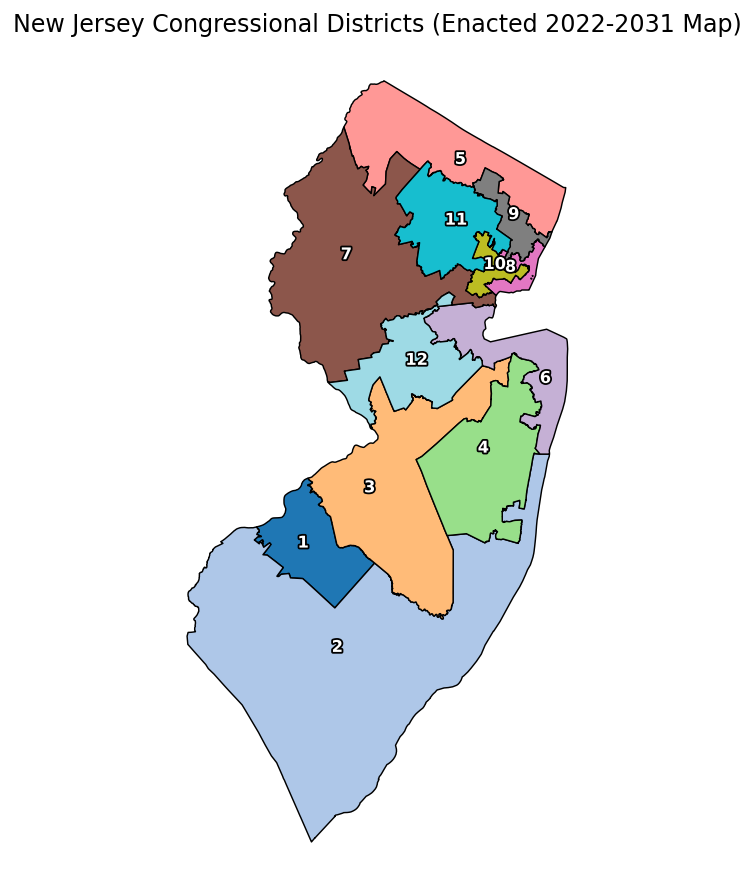

In [5]:
# Figure: district map
nj_geo = nj.to_crs(4326)
fig, ax = plt.subplots(figsize=(6, 7))
nj_geo.plot(column="District", cmap="tab20", edgecolor="black", linewidth=0.8, ax=ax)
for _, row in nj_geo.iterrows():
    c = row.geometry.representative_point()
    ax.annotate(str(row["District"]), (c.x, c.y), ha="center", va="center",
                fontsize=9, fontweight="bold", color="white",
                path_effects=[pe.withStroke(linewidth=2, foreground="black")])
ax.set_title("New Jersey Congressional Districts (Enacted 2022-2031 Map)")
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGS / "fig1_districts_map.png", dpi=150)
plt.show()

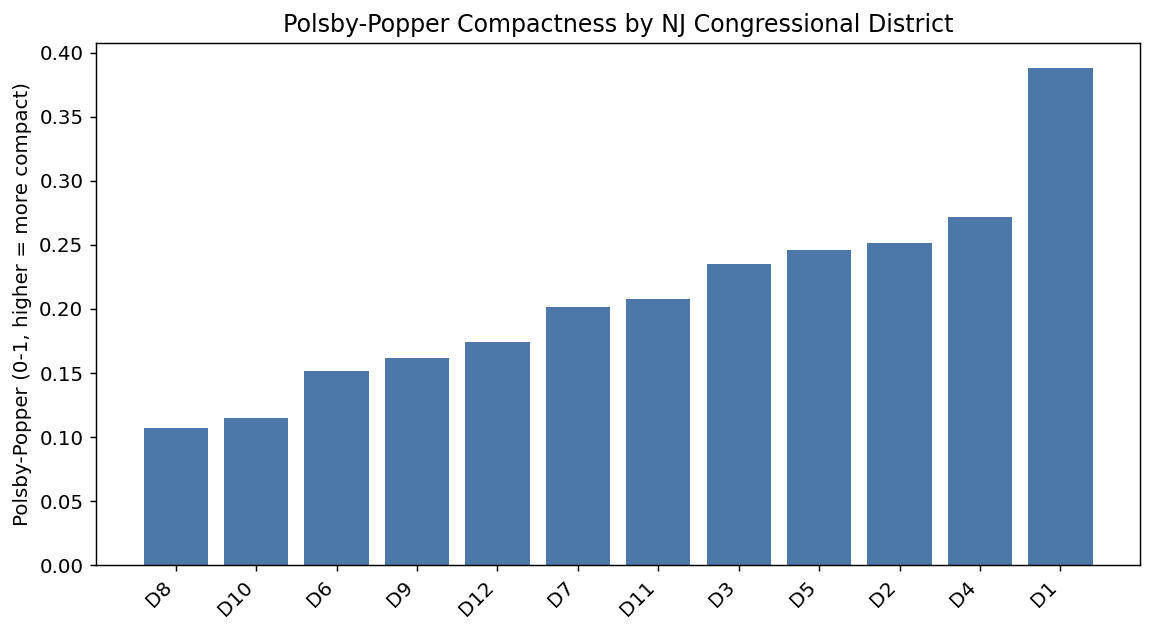

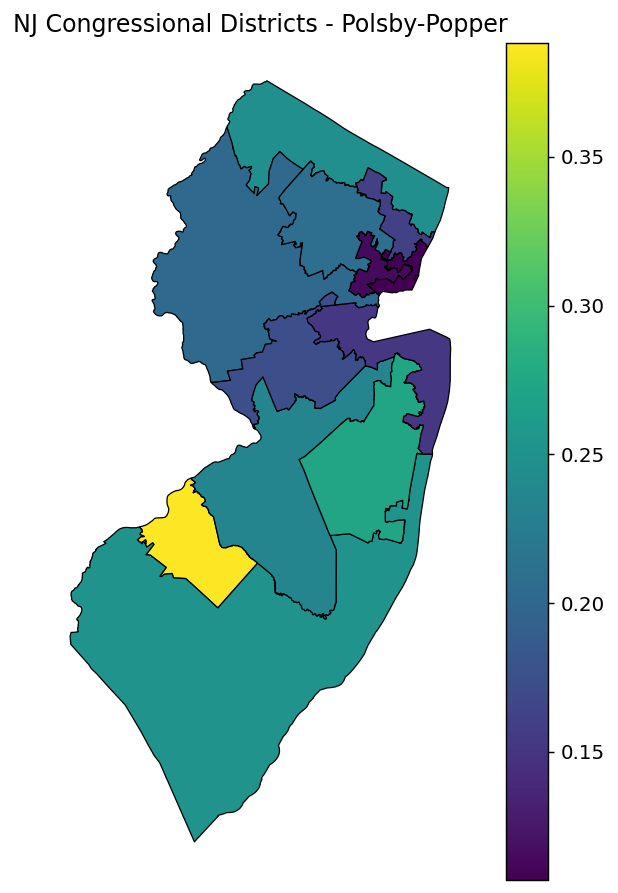

In [6]:
# Figure: Polsby-Popper bar chart + choropleth
order = compactness.sort_values("polsby_popper")
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([f"D{d}" for d in order["District"]], order["polsby_popper"], color="#4C78A8")
ax.set_title("Polsby-Popper Compactness by NJ Congressional District")
ax.set_ylabel("Polsby-Popper (0-1, higher = more compact)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGS / "fig7_polsby_popper_bar.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 7))
nj_geo.merge(compactness, on="District").plot(column="polsby_popper", cmap="viridis",
                                                legend=True, edgecolor="black", linewidth=0.7, ax=ax)
ax.set_title("NJ Congressional Districts - Polsby-Popper")
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGS / "fig8_polsby_popper_map.png", dpi=150)
plt.show()

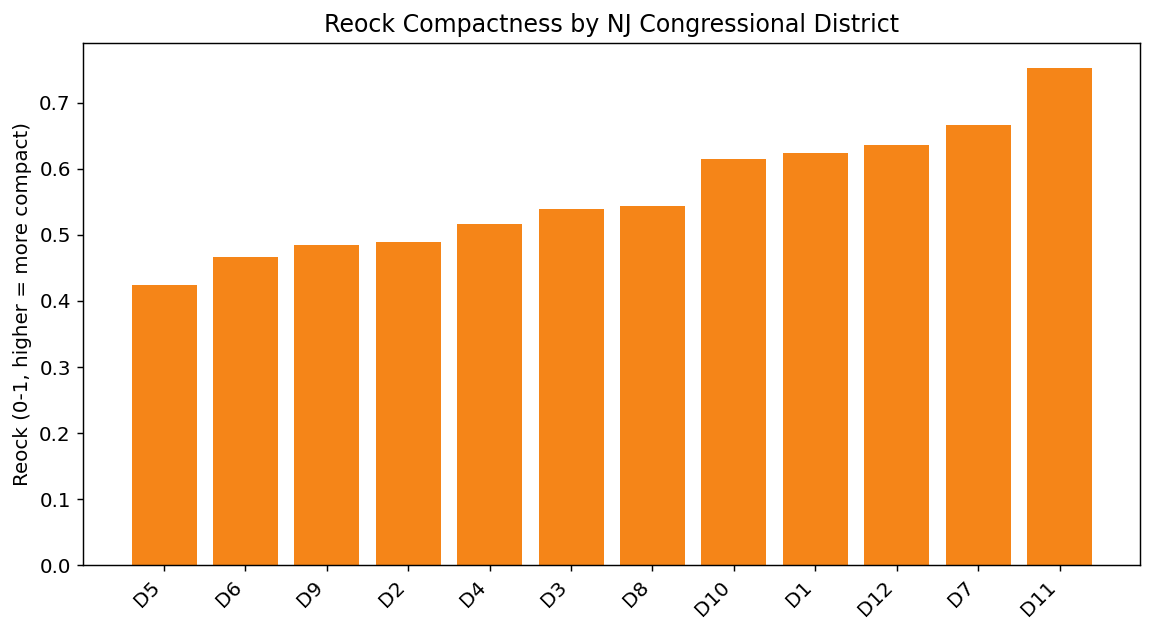

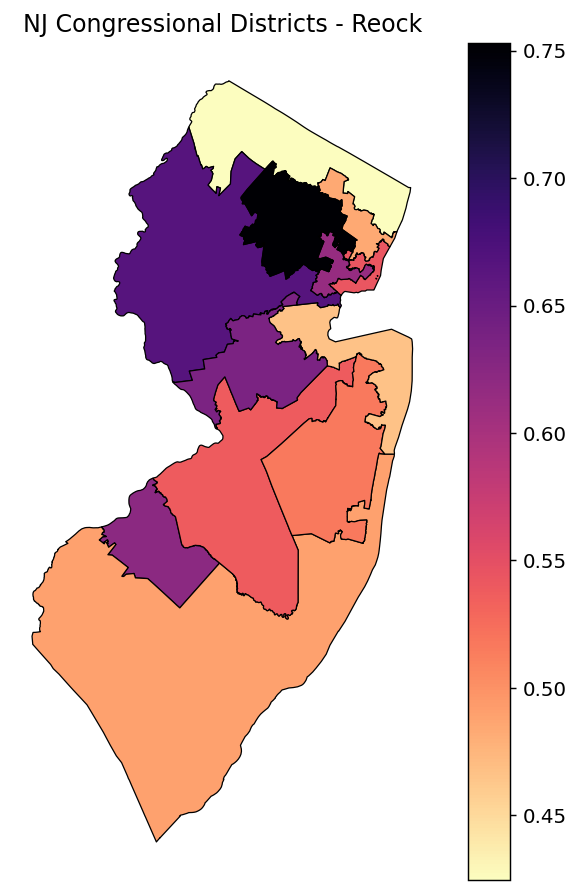

In [7]:
# Figure: Reock bar chart + choropleth
order = compactness.sort_values("reock")
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([f"D{d}" for d in order["District"]], order["reock"], color="#F58518")
ax.set_title("Reock Compactness by NJ Congressional District")
ax.set_ylabel("Reock (0-1, higher = more compact)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGS / "fig9_reock_bar.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 7))
nj_geo.merge(compactness, on="District").plot(column="reock", cmap="magma_r",
                                                legend=True, edgecolor="black", linewidth=0.7, ax=ax)
ax.set_title("NJ Congressional Districts - Reock")
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGS / "fig10_reock_map.png", dpi=150)
plt.show()

## Section 2 — Population Deviation

Population totals below are the New Jersey Redistricting Commission's own official
counts for the enacted map (`data/population_demographics.csv`), not a re-pull from the
Census API — this is the single most important correction from the earlier draft,
which had accidentally computed deviation on the *old*, pre-redistricting map.


In [8]:
pop = pd.read_csv(DATA / "population_demographics.csv")
ideal_pop = pop["TotalPop"].mean()
pop["Deviation_pct"] = (pop["TotalPop"] - ideal_pop) / ideal_pop * 100

print(f"Ideal population: {ideal_pop:,.0f}")
print(f"Max deviation: {pop['Deviation_pct'].max():+.4f}%")
print(f"Min deviation: {pop['Deviation_pct'].min():+.4f}%")
print(f"Total range: {pop['Deviation_pct'].max() - pop['Deviation_pct'].min():.4f}%")
pop[["District", "TotalPop", "Deviation_pct"]]

Ideal population: 773,585
Max deviation: +0.0002%
Min deviation: -0.0001%
Total range: 0.0003%


,District,TotalPop,Deviation_pct
0,1,773585,0.000043
1,2,773584,-0.000086
2,3,773586,0.000172
3,4,773586,0.000172
4,5,773585,0.000043
5,6,773586,0.000172
6,7,773584,-0.000086
7,8,773584,-0.000086
8,9,773584,-0.000086
9,10,773584,-0.000086


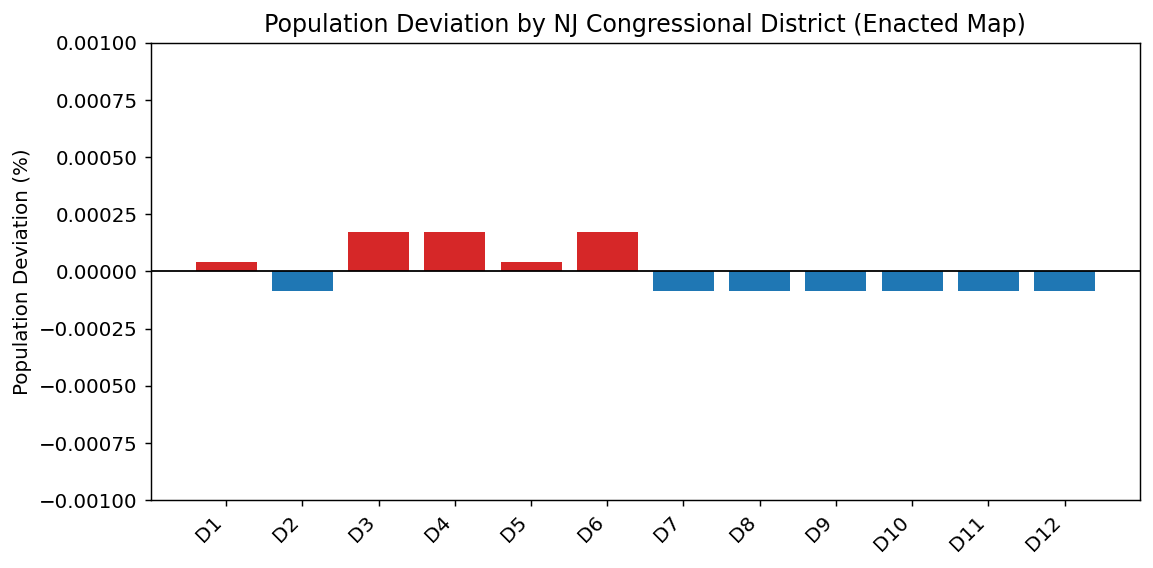

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([f"D{d}" for d in pop["District"]], pop["Deviation_pct"],
       color=["#d62728" if v > 0 else "#1f77b4" for v in pop["Deviation_pct"]])
ax.axhline(0, color="k", linewidth=1)
ax.set_ylim(-0.001, 0.001)
ax.set_ylabel("Population Deviation (%)")
ax.set_title("Population Deviation by NJ Congressional District (Enacted Map)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGS / "fig11_pop_deviation.png", dpi=150)
plt.show()

## Section 3 — Demographics and Majority-Minority Classification

Majority-minority status is based on **total population** shares (not CVAP or VAP),
matching the convention used in the Commission's own demographic report (see paper
Section 3.5 for the justification and CVAP/VAP as a noted limitation).


In [10]:
pop["pct_Hispanic"] = pop["Hispanic"] / pop["TotalPop"]
pop["pct_White"] = pop["NH_White"] / pop["TotalPop"]
pop["pct_Black"] = pop["NH_Black"] / pop["TotalPop"]
pop["pct_Asian"] = pop["NH_Asian"] / pop["TotalPop"]
pop["pct_Nonwhite"] = 1 - pop["pct_White"]
pop["coalition_pct"] = (pop["Hispanic"] + pop["NH_Black"] + pop["NH_Asian"]) / pop["TotalPop"]

pop["majority_hispanic"] = pop["pct_Hispanic"] >= 0.5
pop["majority_minority_coalition"] = pop["coalition_pct"] >= 0.5

pop[["District", "pct_Hispanic", "pct_White", "pct_Black", "pct_Asian",
     "coalition_pct", "majority_hispanic", "majority_minority_coalition"]].round(3)

,District,pct_Hispanic,pct_White,pct_Black,pct_Asian,coalition_pct,majority_hispanic,majority_minority_coalition
0,1,0.149,0.594,0.160,0.053,0.363,False,False
1,2,0.173,0.639,0.108,0.038,0.319,False,False
2,3,0.113,0.635,0.120,0.085,0.319,False,False
3,4,0.103,0.804,0.033,0.025,0.161,False,False
4,5,0.162,0.592,0.052,0.159,0.373,False,False
5,6,0.245,0.418,0.104,0.193,0.542,False,True
6,7,0.122,0.708,0.048,0.083,0.252,False,False
7,8,0.510,0.249,0.078,0.118,0.706,True,True
8,9,0.415,0.382,0.081,0.090,0.587,False,True
9,10,0.213,0.188,0.486,0.063,0.763,False,True


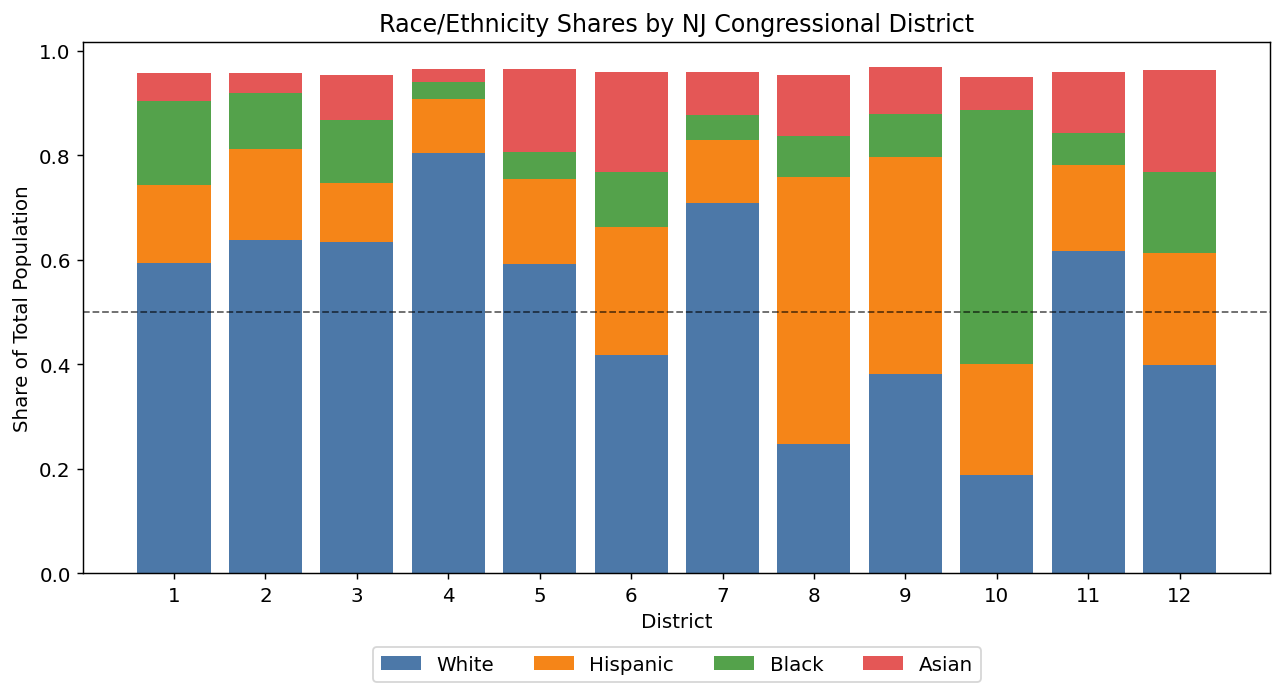

In [11]:
# Figure: race/ethnicity shares stacked bar with 50% line
fig, ax = plt.subplots(figsize=(10, 5.5))
bottom = np.zeros(12)
for col, label, color in [("pct_White", "White", "#4C78A8"), ("pct_Hispanic", "Hispanic", "#F58518"),
                            ("pct_Black", "Black", "#54A24B"), ("pct_Asian", "Asian", "#E45756")]:
    ax.bar(pop["District"].astype(str), pop[col], bottom=bottom, label=label, color=color)
    bottom += pop[col].to_numpy()
ax.axhline(0.5, color="k", ls="--", lw=1, alpha=0.6)
ax.set_title("Race/Ethnicity Shares by NJ Congressional District")
ax.set_ylabel("Share of Total Population")
ax.set_xlabel("District")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.savefig(FIGS / "fig12_race_shares.png", dpi=150)
plt.show()

## Section 4 — Partisan Metrics (Efficiency Gap, Mean-Median Difference, Partisan Bias)

Vote totals are the certified, two-party 2022 NJ general election results for U.S. House
(`data/election_results_2022_us_house.csv`), sourced from the NJ Division of Elections.


In [12]:
votes = pd.read_csv(DATA / "election_results_2022_us_house.csv")
votes["Total"] = votes["Dem_votes"] + votes["Rep_votes"]
votes["Dem_share"] = votes["Dem_votes"] / votes["Total"]

def wasted(dem, rep, total):
    threshold = total / 2 + 1
    if dem > rep:
        return dem - threshold, rep
    else:
        return dem, rep - threshold

votes[["Dem_waste", "Rep_waste"]] = votes.apply(
    lambda r: pd.Series(wasted(r["Dem_votes"], r["Rep_votes"], r["Total"])), axis=1)

eff_gap = (votes["Dem_waste"].sum() - votes["Rep_waste"].sum()) / votes["Total"].sum()
print(f"Efficiency Gap: {eff_gap:.4f}")
votes

Efficiency Gap: -0.0907


,District,Dem_votes,Rep_votes,Total,Dem_share,Dem_waste,Rep_waste
0,1,139559,78794,218353,0.639144,30381.5,78794.0
1,2,94522,139217,233739,0.404391,94522.0,22346.5
2,3,150498,118415,268913,0.559653,16040.5,118415.0
3,4,81233,173288,254521,0.319160,81233.0,46026.5
4,5,145559,117873,263432,0.552549,13842.0,117873.0
5,6,106238,75839,182077,0.583478,15198.5,75839.0
6,7,150701,159392,310093,0.485986,150701.0,4344.5
7,8,78382,24957,103339,0.758494,26711.5,24957.0
8,9,82457,65365,147822,0.557813,8545.0,65365.0
9,10,100710,25993,126703,0.794851,37357.5,25993.0


In [13]:
mean_share = votes["Dem_share"].mean()
median_share = votes["Dem_share"].median()
mmd = mean_share - median_share
print(f"Mean Democratic Vote Share: {mean_share:.4f}")
print(f"Median Democratic Vote Share: {median_share:.4f}")
print(f"Mean-Median Difference: {mmd:.4f}")

Mean Democratic Vote Share: 0.5740
Median Democratic Vote Share: 0.5716
Mean-Median Difference: 0.0024


In [14]:
# Partisan bias: uniform swing to bring statewide vote to 50-50
current_dem_share = votes["Dem_votes"].sum() / votes["Total"].sum()
swing = 0.5 - current_dem_share
votes["Dem_50"] = votes["Dem_votes"] + swing * votes["Total"]
votes["Rep_50"] = votes["Total"] - votes["Dem_50"]
votes["Dem_wins_50"] = votes["Dem_50"] > votes["Rep_50"]

dem_seats_50 = votes["Dem_wins_50"].sum()
partisan_bias = dem_seats_50 / len(votes) - 0.5
print(f"At a hypothetical 50-50 statewide vote, Democrats win {dem_seats_50} of {len(votes)} seats.")
print(f"Partisan Bias: {partisan_bias:+.4f}")
votes[["District", "Dem_50", "Rep_50", "Dem_wins_50"]]

At a hypothetical 50-50 statewide vote, Democrats win 9 of 12 seats.
Partisan Bias: +0.2500


,District,Dem_50,Rep_50,Dem_wins_50
0,1,128705.169146,89647.830854,True
1,2,82903.366091,150835.633909,False
2,3,137130.946575,131782.053425,True
3,4,68581.340152,185939.659848,False
4,5,132464.394615,130967.605385,True
5,6,97187.366574,84889.633426,True
6,7,135286.982464,174806.017536,False
7,8,73245.253417,30093.746583,True
8,9,75109.104690,72712.895310,True
9,10,94411.882133,32291.117867,True


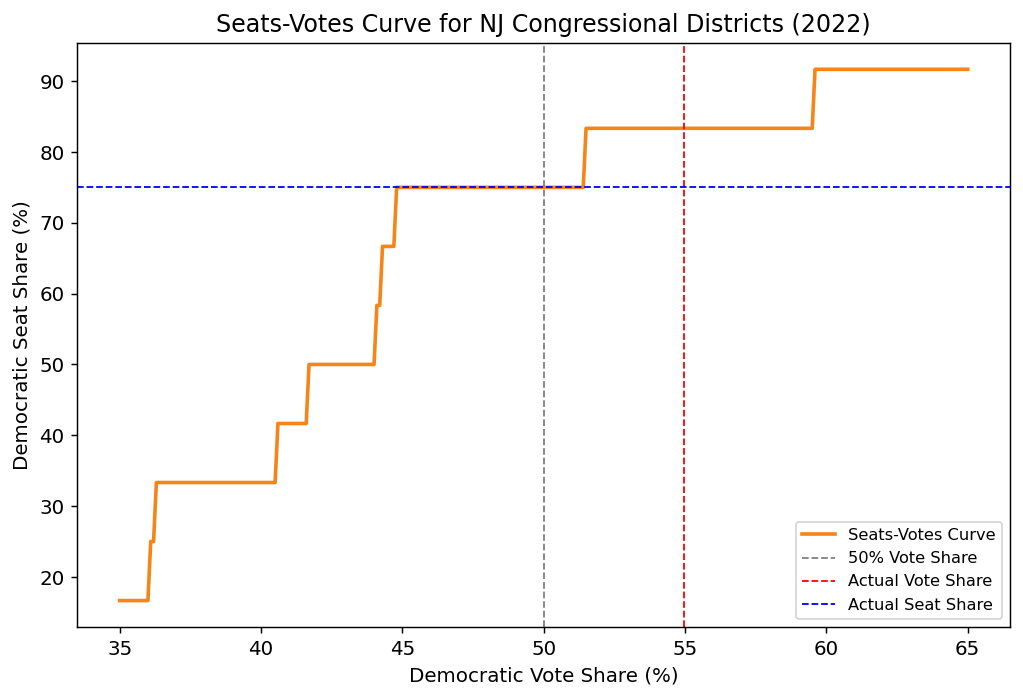

Symmetry Score: 0.0167


In [15]:
# Seats-votes curve + symmetry score
swings = np.linspace(-0.15, 0.15, 301)
seat_shares = np.array([(votes["Dem_share"] + s > 0.5).mean() for s in swings])

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot((0.5 + swings) * 100, seat_shares * 100, color="#F58518", lw=2, label="Seats-Votes Curve")
ax.axvline(50, color="gray", ls="--", lw=1, label="50% Vote Share")
ax.axvline(current_dem_share * 100, color="red", ls="--", lw=1, label="Actual Vote Share")
ax.axhline((votes["Dem_share"] > 0.5).mean() * 100, color="blue", ls="--", lw=1, label="Actual Seat Share")
ax.set_xlabel("Democratic Vote Share (%)"); ax.set_ylabel("Democratic Seat Share (%)")
ax.set_title("Seats-Votes Curve for NJ Congressional Districts (2022)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "fig6_seats_votes.png", dpi=150)
plt.show()

# Symmetry score: mirror seat share around a range of vote shares centered on 50%,
# following the same method as the original analysis (shift each district's share so
# the statewide mean lands on a test value v, for v spanning 40%-60% in 1% steps).
vote_shares_test = np.linspace(0.4, 0.6, 21)
dem_seat_shares = []
for v in vote_shares_test:
    shifted = votes["Dem_share"] - (votes["Dem_share"].mean() - v)
    dem_seat_shares.append((shifted > 0.5).mean())

symmetry_diffs = []
for i in range(len(vote_shares_test) // 2):
    left = dem_seat_shares[i]
    right = dem_seat_shares[-(i + 1)]
    symmetry_diffs.append(right - (1 - left))

symmetry_score = np.mean(symmetry_diffs)
print(f"Symmetry Score: {symmetry_score:.4f}")

## Section 5 — Correlation: Demographic Composition vs. Democratic Vote Share


In [16]:
merged = pop.merge(votes[["District", "Dem_share"]], on="District")

results = {}
for col, label in [("pct_Hispanic", "Hispanic share"), ("pct_Nonwhite", "Nonwhite share"),
                    ("coalition_pct", "Black+Hispanic+Asian share")]:
    r, p = pearsonr(merged[col], merged["Dem_share"])
    slope, intercept = np.polyfit(merged[col], merged["Dem_share"], 1)
    resid = merged["Dem_share"] - (slope * merged[col] + intercept)
    r2 = 1 - np.sum(resid**2) / np.sum((merged["Dem_share"] - merged["Dem_share"].mean())**2)
    results[label] = (r, p, r2)
    print(f"{label:30s} r={r: .3f}  p={p:.4f}  R2={r2: .3f}")

Hispanic share                 r= 0.506  p=0.0932  R2= 0.256
Nonwhite share                 r= 0.854  p=0.0004  R2= 0.729
Black+Hispanic+Asian share     r= 0.846  p=0.0005  R2= 0.716


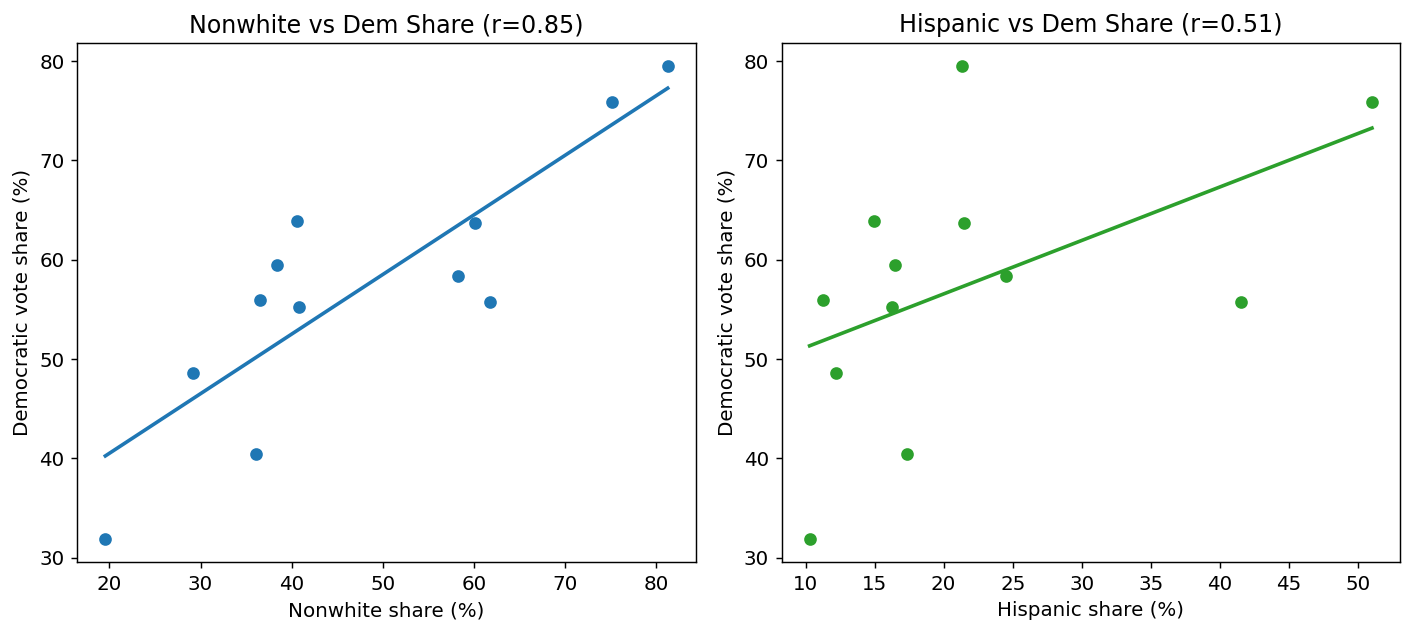

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, col, label, color in [(axes[0], "pct_Nonwhite", "Nonwhite share (%)", "tab:blue"),
                                (axes[1], "pct_Hispanic", "Hispanic share (%)", "tab:green")]:
    x = merged[col].to_numpy(); y = merged["Dem_share"].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    r, p = pearsonr(x, y)
    ax.scatter(x * 100, y * 100, color=color)
    xx = np.linspace(x.min(), x.max(), 50)
    ax.plot(xx * 100, (slope * xx + intercept) * 100, color=color, lw=2)
    ax.set_xlabel(label); ax.set_ylabel("Democratic vote share (%)")
    ax.set_title(f"{label.split(' share')[0]} vs Dem Share (r={r:.2f})")
plt.tight_layout()
plt.savefig(FIGS / "fig13_correlation_scatter.png", dpi=150)
plt.show()

## Section 6 — Income, Education, Age (descriptive profile)

These were already computed on the correct (118th Congress) map in the original draft,
since a 2022-vintage ACS pull maps to current district boundaries. They're bundled here
as `data/income_education_age.csv` for convenience, with the live API pull commented
out below (needs your own Census API key — free at https://api.census.gov/data/key_signup.html).


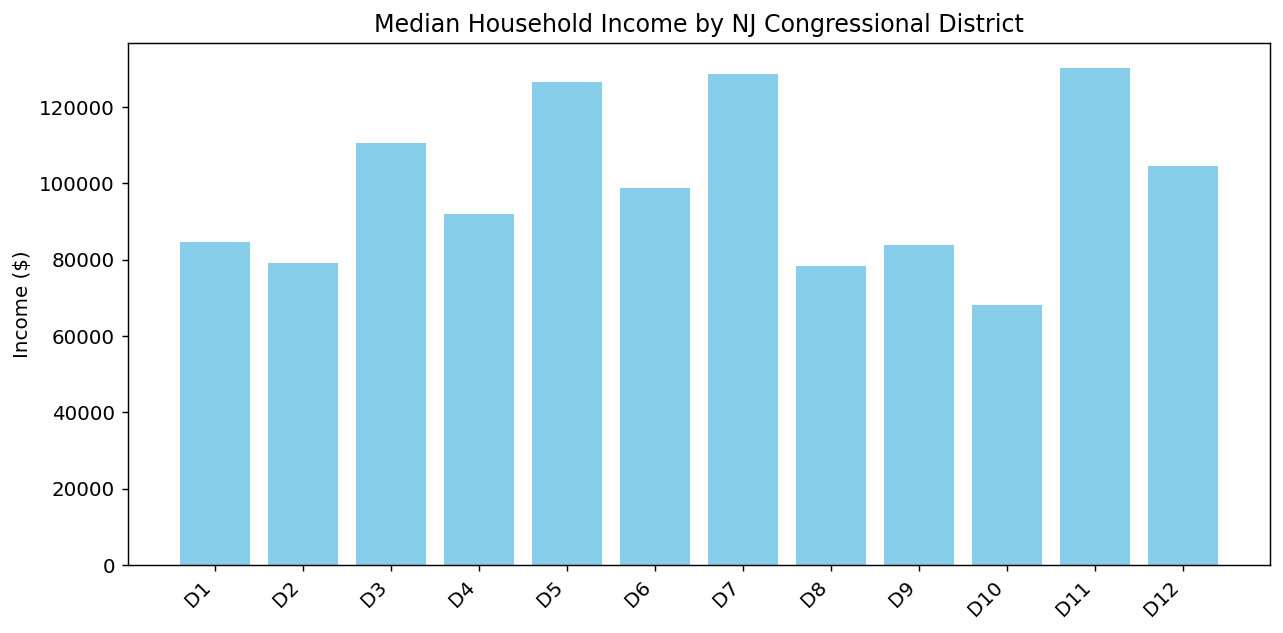

In [18]:
iea = pd.read_csv(DATA / "income_education_age.csv")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([f"D{d}" for d in iea["District"]], iea["MedianIncome"], color="skyblue")
ax.set_title("Median Household Income by NJ Congressional District")
ax.set_ylabel("Income ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGS / "fig3_income.png", dpi=150)
plt.show()

In [19]:
# --- Optional: re-pull income/education/age live from the Census API ---
# import requests
# API_KEY = "YOUR_KEY_HERE"  # https://api.census.gov/data/key_signup.html
# url = (f"https://api.census.gov/data/2022/acs/acs5?get=NAME,B19013_001E"
#        f"&for=congressional%20district:*&in=state:34&key={API_KEY}")
# r = requests.get(url); data = r.json()
# income_live = pd.DataFrame(data[1:], columns=data[0])
# NOTE: 2022-vintage (or later) ACS "congressional district" geography returns the
# CURRENT (118th Congress) boundaries -- do NOT use 2020-vintage queries for anything
# tied to district geometry, since that vintage returns the retired 116th-Congress map.

## Notes on Reproducibility

- Every number in the paper can be reproduced by running this notebook top to bottom.
- The only external network call is the TIGER/Line shapefile download in Section 1;
  everything else reads from the bundled CSVs in `data/`, each with its exact primary
  source documented in the table at the top of this notebook and in the paper's
  Section 3.2.
- No outlier removal, standardization, or normalization is applied anywhere: all
  inputs are administrative totals (Census counts, certified vote totals), and the
  fairness metrics themselves are ratios, which are scale-invariant.
